# Stage 2 — Cleaning + Harmonization

Turns the raw GBIF SIMPLE_CSV extracts (`data/interim/`) into analysis-ready
tables (`data/processed/`) and tidies the CDC establishment workbook. **No
effort ratio / range estimation here — that is Stage 3.**

The heavy lifting lives in `src/clean.py` (config-driven via `src/config.py`).
This notebook *runs* that pipeline and reports on it:

1. **Cleaning ledger** — row count in/out at every filter + dedup step, both datasets.
2. **`source_type` breakdown** — NEON (systematic) vs iNaturalist (opportunistic) vs other.
3. **Map** of *A. americanum* colored by `source_type` (NEON fixed-site clustering vs iNat spread).
4. **Records-per-hex** distribution (H3 res 5).

Both the target (*A. americanum*) and the Ixodidae background pass through the
**identical** functions — the background is the effort denominator and must be
comparable to the numerator.

> **Key Stage-2 finding:** the ~14.6k blank-`institutionCode` *A. americanum*
> records are **NEON drag-cloth sampling** (dataset `12315bb8-…`,
> SAMPLING_EVENT, published by the NEON org), **not** iNaturalist as initially
> assumed. Verified against the GBIF registry. Source tagging therefore keys on
> `publishingOrganizationKey`, not `institutionCode`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

# Make src/ importable (config.py, clean.py) regardless of cwd.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import config
import clean

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Config knobs in play this run:")
print(f"  H3_RESOLUTION                = {config.H3_RESOLUTION}")
print(f"  MAX_COORDINATE_UNCERTAINTY_M = {config.MAX_COORDINATE_UNCERTAINTY_M:,.0f} m")
print(f"  DEDUP_COORD_DECIMALS         = {config.DEDUP_COORD_DECIMALS}")
print(f"  DEDUP_CROSS_SOURCE_ONLY      = {config.DEDUP_CROSS_SOURCE_ONLY}")
print(f"  DENSE_SIGNAL_START_YEAR      = {config.DENSE_SIGNAL_START_YEAR}")
print(f"  RAW_CRS -> ANALYSIS_CRS      = {config.RAW_CRS} -> {config.ANALYSIS_CRS}")

Config knobs in play this run:
  H3_RESOLUTION                = 5
  MAX_COORDINATE_UNCERTAINTY_M = 10,000 m
  DEDUP_COORD_DECIMALS         = 5
  DEDUP_CROSS_SOURCE_ONLY      = True
  DENSE_SIGNAL_START_YEAR      = 2015
  RAW_CRS -> ANALYSIS_CRS      = EPSG:4326 -> EPSG:5070


## 1. Run the Stage 2 pipeline

`clean.run_stage2()` cleans **both** occurrence datasets through identical
functions, harmonizes the CDC table, and writes the regenerable outputs to
`data/processed/` (parquet for occurrences, CSV for CDC, JSON for the ledger).
`data/raw/` and `data/interim/` are never touched.

In [2]:
out = clean.run_stage2(write=True)

target = out["target"]
background = out["background"]
cdc = out["cdc"]
ledger = out["ledger"]

print(f"target     (A. americanum): {len(target):>8,} rows, {target.shape[1]} cols")
print(f"background  (Ixodidae):     {len(background):>8,} rows, {background.shape[1]} cols")
print(f"CDC counties:               {len(cdc):>8,} rows")
print("\nProcessed outputs written to:", config.PROCESSED_DIR)
for p in sorted(config.PROCESSED_DIR.glob("*")):
    print("  -", p.name)

22:15:14 | INFO    | Loaded gbif_amblyomma_americanum_us_2026-06-03_n38916.csv (38916 rows, 17 cols)


22:15:14 | INFO    | [target] load interim                    38916 ->    38916 (removed      0,  0.00%) gbif_amblyomma_americanum_us_2026-06-03_n38916.csv


22:15:14 | INFO    | [target] standardize types               38916 ->    38916 (removed      0,  0.00%) 


22:15:14 | INFO    | [target] tag source_type                 38916 ->    38916 (removed      0,  0.00%) 


22:15:14 | INFO    | [target] drop null coordinates           38916 ->    38916 (removed      0,  0.00%) 


...

22:15:23 | INFO    | [background] trim to keep columns           411641 ->   411641 (removed      0,  0.00%) 23 cols


22:15:24 | INFO    | Loaded CDC workbook cdc_amblyomma_americanum_established_2026-06-03.xlsx (3110 rows)


22:15:24 | INFO    | CDC tidy: 3110 counties | established=1139 reported=635 other=1336


22:15:25 | INFO    | Wrote processed outputs -> C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\data\processed


target     (A. americanum):   38,916 rows, 23 cols
background  (Ixodidae):      411,641 rows, 23 cols
CDC counties:                  3,110 rows

Processed outputs written to: C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\data\processed
  - .gitkeep
  - amblyomma_americanum_clean.parquet
  - cdc_amblyomma_americanum_established_tidy.csv
  - ixodidae_background_clean.parquet
  - stage2_cleaning_ledger.json


## 2. Cleaning ledger — rows in/out at every step

One row per (dataset, step). `rows_in -> rows_out` with the count and percent
removed. Coordinate-quality and dedup rules are logged individually so the audit
trail is complete.

In [3]:
def show_ledger(name: str) -> pd.DataFrame:
    cols = ["step", "rows_in", "rows_out", "removed", "pct_removed", "note"]
    sub = ledger[ledger["dataset"] == name][cols].reset_index(drop=True)
    return sub

print("=== TARGET  (Amblyomma americanum) ===")
display(show_ledger("target"))
print("\n=== BACKGROUND  (Ixodidae effort denominator) ===")
display(show_ledger("background"))

# Net summary: first load count -> final kept count, per dataset.
summary = (
    ledger.groupby("dataset")
    .agg(loaded=("rows_in", "first"), final=("rows_out", "last"))
    .assign(total_removed=lambda d: d["loaded"] - d["final"],
            pct_kept=lambda d: (100 * d["final"] / d["loaded"]).round(2))
)
print("\nNet result:")
display(summary)

=== TARGET  (Amblyomma americanum) ===


,step,rows_in,rows_out,removed,pct_removed,note
0,load interim,38916,38916,0,0.0,gbif_amblyomma_americanum_us_2026-06-03_n38916...
1,standardize types,38916,38916,0,0.0,
2,tag source_type,38916,38916,0,0.0,
3,drop null coordinates,38916,38916,0,0.0,
4,drop zero coordinates,38916,38916,0,0.0,
5,drop bad coord issue flags,38916,38916,0,0.0,"flags=['COORDINATE_INVALID', 'COORDINATE_OUT_O..."
6,flag hex_reliable=False,38916,38916,0,0.0,"max=10000m; flagged=937 (kept, not dropped); b..."
7,drop duplicate occurrenceID,38916,38916,0,0.0,
8,drop cross-source dups,38916,38916,0,0.0,cross-source coord/date collisions only
9,reproject+h3+temporal,38916,38916,0,0.0,"EPSG:5070, h3 res 5"



=== BACKGROUND  (Ixodidae effort denominator) ===


,step,rows_in,rows_out,removed,pct_removed,note
0,load interim,411644,411644,0,0.000,gbif_ixodidae_background_us_2026-06-04_n411644...
1,standardize types,411644,411644,0,0.000,
2,tag source_type,411644,411644,0,0.000,
3,drop null coordinates,411644,411644,0,0.000,
4,drop zero coordinates,411644,411644,0,0.000,
5,drop bad coord issue flags,411644,411644,0,0.000,"flags=['COORDINATE_INVALID', 'COORDINATE_OUT_O..."
6,flag hex_reliable=False,411644,411644,0,0.000,"max=10000m; flagged=4266 (kept, not dropped); ..."
7,drop duplicate occurrenceID,411644,411644,0,0.000,
8,drop cross-source dups,411644,411641,3,0.001,cross-source coord/date collisions only
9,reproject+h3+temporal,411641,411641,0,0.000,"EPSG:5070, h3 res 5"



Net result:


,loaded,final,total_removed,pct_kept
dataset,,,,
background,411644,411641,3,100.0
target,38916,38916,0,100.0


## 3. `source_type` breakdown (the critical step)

Sources are kept **separable**: NEON (systematic drag-cloth + biorepository),
iNaturalist (opportunistic citizen science), and other (museum / preserved).
Classification keys on `publishingOrganizationKey` first. Note how NEON
dominates raw counts in **both** datasets — that systematic mass is exactly why
the background needs source-aware effort handling in Stage 3.

TARGET source_type:


,records,pct
source_type,,
NEON,30656,78.77
iNaturalist,7873,20.23
other,387,0.99


BACKGROUND source_type:


,records,pct
source_type,,
NEON,362862,88.15
iNaturalist,37813,9.19
other,10966,2.66


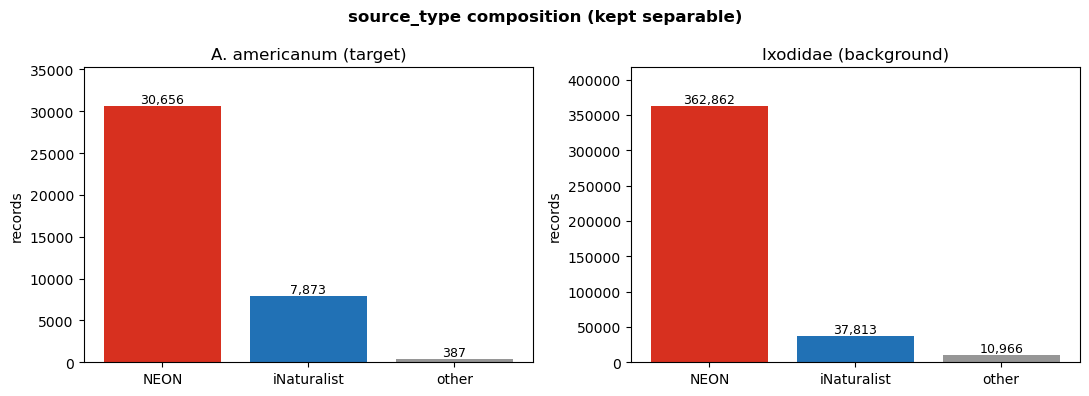

TARGET hex_reliable x source_type (flagged False = 937):


hex_reliable,hex_reliable=True,hex_reliable=False,total
source_type,,,
NEON,30656,0,30656
iNaturalist,6947,926,7873
other,376,11,387
ALL,37979,937,38916


BACKGROUND hex_reliable x source_type (flagged False = 4,266):


hex_reliable,hex_reliable=True,hex_reliable=False,total
source_type,,,
NEON,362862,0,362862
iNaturalist,33935,3878,37813
other,10578,388,10966
ALL,407375,4266,411641


In [4]:
SRC_ORDER = [config.SRC_NEON, config.SRC_INAT, config.SRC_OTHER]
SRC_COLORS = {config.SRC_NEON: "#d7301f",        # systematic — red
              config.SRC_INAT: "#2171b5",        # citizen science — blue
              config.SRC_OTHER: "#969696"}       # museum/other — grey

def source_table(df: pd.DataFrame) -> pd.DataFrame:
    counts = df["source_type"].value_counts().reindex(SRC_ORDER).fillna(0).astype(int)
    pct = (100 * counts / counts.sum()).round(2)
    return pd.DataFrame({"records": counts, "pct": pct})

tgt_src = source_table(target)
bg_src = source_table(background)
print("TARGET source_type:")
display(tgt_src)
print("BACKGROUND source_type:")
display(bg_src)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tbl, title in [(axes[0], tgt_src, "A. americanum (target)"),
                       (axes[1], bg_src, "Ixodidae (background)")]:
    colors = [SRC_COLORS[s] for s in tbl.index]
    ax.bar(tbl.index, tbl["records"], color=colors)
    ax.set_title(title)
    ax.set_ylabel("records")
    for i, v in enumerate(tbl["records"]):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
    ax.margins(y=0.15)
fig.suptitle("source_type composition (kept separable)", fontweight="bold")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "stage2_source_type_breakdown.png", dpi=150,
            bbox_inches="tight")
plt.show()

# hex_reliable flag x source_type (records coarser than the 10 km cutoff are
# kept but flagged out of the fine density surface).
def hex_reliable_table(df: pd.DataFrame) -> pd.DataFrame:
    ct = (
        pd.crosstab(df["source_type"], df["hex_reliable"])
        .reindex(index=SRC_ORDER)
        .reindex(columns=[True, False], fill_value=0)
        .rename(columns={True: "hex_reliable=True", False: "hex_reliable=False"})
        .fillna(0).astype(int)
    )
    ct["total"] = ct.sum(axis=1)
    ct.loc["ALL"] = ct.sum()
    return ct

print(f"TARGET hex_reliable x source_type "
      f"(flagged False = {int((~target['hex_reliable']).sum()):,}):")
display(hex_reliable_table(target))
print(f"BACKGROUND hex_reliable x source_type "
      f"(flagged False = {int((~background['hex_reliable']).sum()):,}):")
display(hex_reliable_table(background))

## 4. Map — *A. americanum* by `source_type`

NEON (red) should cluster tightly at its fixed field sites; iNaturalist (blue)
should spread broadly across populated areas — the visual signature of the
systematic-vs-opportunistic difference we must respect in Stage 3. Plotted in
the CONUS view (the few AK/HI points are off-frame by design).

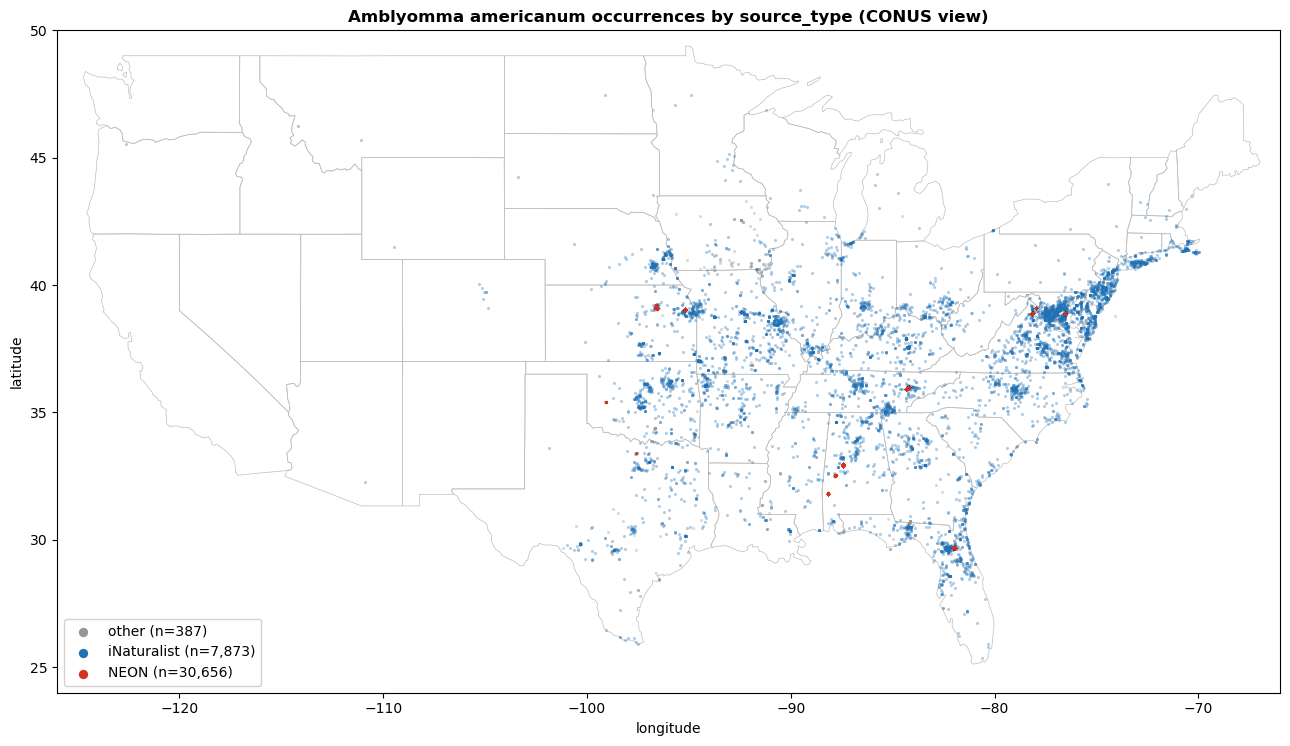

In [5]:
states = gpd.read_file(config.INTERIM_DIR / "us_states.geojson")
CONUS = dict(xlim=(-126, -66), ylim=(24, 50))  # drop AK/HI/PR from the view

fig, ax = plt.subplots(figsize=(13, 7.5))
states.boundary.plot(ax=ax, color="#bdbdbd", linewidth=0.5, zorder=1)

# Plot opportunistic first, systematic on top, so NEON clusters stay visible.
for src in [config.SRC_OTHER, config.SRC_INAT, config.SRC_NEON]:
    sub = target[target["source_type"] == src]
    ax.scatter(sub["decimalLongitude"], sub["decimalLatitude"],
               s=5, alpha=0.35, linewidths=0,
               color=SRC_COLORS[src], label=f"{src} (n={len(sub):,})", zorder=2)

ax.set_xlim(*CONUS["xlim"])
ax.set_ylim(*CONUS["ylim"])
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Amblyomma americanum occurrences by source_type (CONUS view)",
             fontweight="bold")
leg = ax.legend(loc="lower left", framealpha=0.9, markerscale=3)
for lh in leg.legend_handles:
    lh.set_alpha(1)
ax.set_aspect(1.25)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "stage2_map_source_type.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 5. Records per H3 cell

How occurrences pile up per hex (res 5), computed on the **`hex_reliable==True`**
subset — that is what the Stage 3 density surface will use. A long right tail = a
few cells (NEON sites, popular parks) holding many records. Shown for both
datasets; counts axis is log-scaled.

hex_reliable subset -> target 37,979/38,916, background 407,375/411,641
Records-per-hex summary (H3 res 5 ):


,target,background
occupied_cells,2201.0,7578.0
records,37979.0,407375.0
median_per_cell,1.0,2.0
mean_per_cell,17.3,53.8
max_per_cell,8863.0,225931.0
p95_per_cell,11.0,21.0


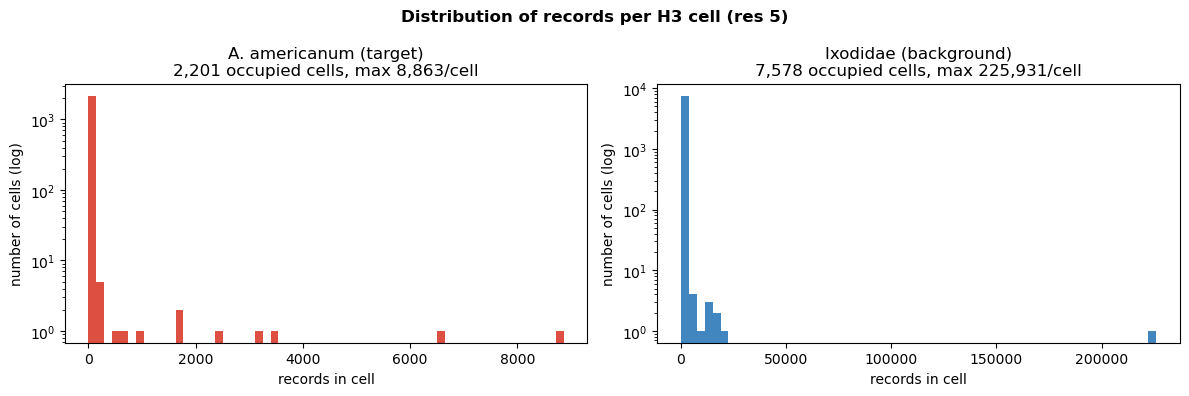

In [6]:
# Density work uses only hex-reliable records (uncertainty <= threshold or NaN).
tgt_hex_src = target[target["hex_reliable"]]
bg_hex_src = background[background["hex_reliable"]]
print(f"hex_reliable subset -> target {len(tgt_hex_src):,}/{len(target):,}, "
      f"background {len(bg_hex_src):,}/{len(background):,}")

tgt_per_hex = tgt_hex_src.groupby("h3_cell").size()
bg_per_hex = bg_hex_src.groupby("h3_cell").size()

def hex_stats(s: pd.Series) -> pd.Series:
    return pd.Series({
        "occupied_cells": s.size,
        "records": int(s.sum()),
        "median_per_cell": float(s.median()),
        "mean_per_cell": round(float(s.mean()), 1),
        "max_per_cell": int(s.max()),
        "p95_per_cell": int(s.quantile(0.95)),
    })

print("Records-per-hex summary (H3 res", config.H3_RESOLUTION, "):")
display(pd.DataFrame({"target": hex_stats(tgt_per_hex),
                      "background": hex_stats(bg_per_hex)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, s, title, color in [
    (axes[0], tgt_per_hex, "A. americanum (target)", "#d7301f"),
    (axes[1], bg_per_hex, "Ixodidae (background)", "#2171b5"),
]:
    ax.hist(s.values, bins=60, color=color, alpha=0.85)
    ax.set_yscale("log")
    ax.set_xlabel("records in cell")
    ax.set_ylabel("number of cells (log)")
    ax.set_title(f"{title}\n{s.size:,} occupied cells, max {int(s.max()):,}/cell")
fig.suptitle(f"Distribution of records per H3 cell (res {config.H3_RESOLUTION})",
             fontweight="bold")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "stage2_records_per_hex.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 6. CDC harmonization (light)

The CDC county establishment workbook, standardized to 5-digit FIPS so it joins
cleanly to results in a later stage. `established` is the canonical sticky /
monotonic footprint; `Reported` and `No records` are retained but flagged
`False`.

In [7]:
print("CDC status composition:")
display(cdc["status"].value_counts(dropna=False).rename_axis("status").to_frame("counties"))
print(f"Established counties: {int(cdc['established'].sum()):,} / {len(cdc):,}")
print("FIPS examples (zero-padded to 5 digits):",
      list(cdc["county_fips"].head(3)), "...", list(cdc["county_fips"].tail(2)))
display(cdc.head(6))

CDC status composition:


,counties
status,
No records,1336
Established,1139
Reported,635


Established counties: 1,139 / 3,110
FIPS examples (zero-padded to 5 digits): ['01001', '01003', '01005'] ... ['56043', '56045']


,county_fips,state,county,status,source,established
0,01001,AL,Autauga County,No records,NaN,False
1,01003,AL,Baldwin County,Established,ArboNET Data,True
2,01005,AL,Barbour County,Reported,Literature,False
3,01007,AL,Bibb County,Established,ArboNET Data,True
4,01009,AL,Blount County,Established,ArboNET Data,True
5,01011,AL,Bullock County,Reported,Literature,False


## 7. Stage 2 summary & open decisions

**Done:** identical cleaning of target + background, type/coordinate
standardization, source tagging (kept separable), EPSG:5070 reprojection, H3
binning, dense-window flag, CDC FIPS harmonization. Outputs in
`data/processed/`; figures in `reports/figures/`. **Stop here — no effort ratio
/ range estimation (Stage 3).**

**Decisions resolved with the user (now locked in `config.py`):**

- **Source classification correction.** Blank-`institutionCode` records are NEON
  drag-cloth sampling, *not* iNaturalist → tagged **NEON systematic** (confirmed).
  Tagging keys on `publishingOrgKey`.
- **Dedup key.** Confirmed: do **not** dedup on coords+date (would collapse
  ~75–90% of records — NEON emits many legitimate records per site/day). We drop
  only exact `occurrenceID` dups + cross-source coord/date collisions
  (0 target / 3 background).
- **Coordinate-uncertainty = 10 km is a hex-reliability FLAG, not a drop.**
  Records coarser than 10 km are kept (carrying raw uncertainty) but flagged
  `hex_reliable=False` (~937 target / ~4,266 bg) so they're excluded from the
  fine density surface; they stay usable for county-level work in Stage 3. NaN
  uncertainty stays reliable.
- **H3 resolution = 5** (~252 km²/cell), confirmed.